# 4. Feature Engineering

### Weather data

Calculate monthly averages per region (mean of all Jans, Febs, etc.), number of heatwave days, drought index, 

Load weather data parquet

In [36]:
import pandas as pd

In [37]:
weather = pd.read_parquet('../Data/Processed/weather_states.parquet')
weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state
116196,2020-07-17 00:00:00+00:00,15.218751,18.850000,11.750000,0.500000,13.722565,Bayern
111738,2008-05-03 00:00:00+00:00,10.746501,15.459001,4.509000,0.000000,12.574260,Bayern
46340,2022-11-03 00:00:00+00:00,8.820833,15.700000,3.100000,1.000000,11.966953,Baden-Württemberg
16754,2006-05-10 00:00:00+00:00,13.452832,18.544500,8.744499,0.000000,10.308830,Rheinland-Pfalz
50002,2011-05-12 00:00:00+00:00,16.274750,21.293499,12.693500,9.600000,16.610792,Sachsen-Anhalt
105589,2013-01-03 00:00:00+00:00,7.821667,9.517500,5.767500,0.900000,27.210379,Schleswig-Holstein
69997,2023-02-03 00:00:00+00:00,5.091667,8.050000,0.150000,8.600001,40.257271,Berlin
14220,2020-12-03 00:00:00+00:00,2.780084,3.365500,2.215500,1.600000,29.237675,Nordrhein-Westfalen
118800,2006-03-02 00:00:00+00:00,-2.804666,0.212000,-4.738000,0.200000,17.654688,Hessen
92237,2019-06-19 00:00:00+00:00,21.581251,27.600000,15.150000,0.800000,16.199999,Saarland


In [38]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125680 entries, 0 to 125679
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   date                 125680 non-null  datetime64[ms, UTC]
 1   temperature_2m_mean  125680 non-null  float32            
 2   temperature_2m_max   125680 non-null  float32            
 3   temperature_2m_min   125680 non-null  float32            
 4   precipitation_sum    125680 non-null  float32            
 5   wind_speed_10m_max   125680 non-null  float32            
 6   state                125680 non-null  object             
dtypes: datetime64[ms, UTC](1), float32(5), object(1)
memory usage: 4.3+ MB


In [39]:
# Extract month and year from datetime

weather['month'] = weather['date'].dt.month
weather['year'] = weather['date'].dt.year
weather['monthyear'] = weather['month'].astype(str) + '_' + weather['year'].astype(str)
weather.sample(5)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear
89046,2010-09-23 00:00:00+00:00,15.901582,22.187000,9.487,8.0,14.039999,Saarland,9,2010,9_2010
86631,2004-02-12 00:00:00+00:00,3.116167,4.737000,0.187,0.0,6.409617,Saarland,2,2004,2_2004
109407,2023-06-18 00:00:00+00:00,19.918753,26.000000,12.700,0.2,9.720000,Schleswig-Holstein,6,2023,6_2023
120641,2011-03-17 00:00:00+00:00,6.316166,7.112000,5.362,0.0,14.917212,Hessen,3,2011,3_2011
111745,2008-05-10 00:00:00+00:00,15.171500,20.009001,10.159,0.0,19.386591,Bayern,5,2008,5_2008


In [40]:
monthly = weather.groupby(['state', 'year', 'month']).agg(
    temp_mean = ('temperature_2m_mean', 'mean'),
    precip_sum = ('precipitation_sum', 'sum')
).reset_index()

monthly

,state,year,month,temp_mean,precip_sum
0,Baden-Württemberg,2003,7,19.441086,56.400002
1,Baden-Württemberg,2003,8,23.156878,18.400000
2,Baden-Württemberg,2003,9,14.583459,25.699999
3,Baden-Württemberg,2003,10,6.437322,91.799995
4,Baden-Württemberg,2003,11,5.571653,58.000000
...,...,...,...,...,...
4123,Thüringen,2024,8,19.984138,72.899994
4124,Thüringen,2024,9,15.468820,88.400002
4125,Thüringen,2024,10,11.061694,62.299999
4126,Thüringen,2024,11,4.483958,53.499996


In [41]:
# Compute baseline temperature and precipitation (long-term monthly mean per Bundesland)
baseline = monthly.groupby(['state', 'month']).agg(
    baseline_temp = ('temp_mean', 'mean'),
    baseline_precip = ('precip_sum', 'mean')
).reset_index()

baseline


,state,month,baseline_temp,baseline_precip
0,Baden-Württemberg,1,0.888582,73.585716
1,Baden-Württemberg,2,1.658827,58.023811
2,Baden-Württemberg,3,4.780743,60.757145
3,Baden-Württemberg,4,9.264582,61.628571
4,Baden-Württemberg,5,13.113695,91.942856
...,...,...,...,...
187,Thüringen,8,18.361685,84.522728
188,Thüringen,9,14.538055,62.849998
189,Thüringen,10,10.015421,59.663635
190,Thüringen,11,5.154050,56.386364


In [42]:
# Calculate flood risk as n days per month with heavy rain based on regional thresholds
# NB - threshold for heavy rain can differ between regions 
# (some regions may have ecological features better able to deal with more rain)

thresholds = weather.groupby(['state','month'])['precipitation_sum'].quantile(0.95).reset_index()
thresholds = thresholds.rename(columns={'precipitation_sum':'rain_thresh'})

weather = weather.merge(thresholds, on=['state','month'])

weather['heavy_rain'] = (weather['precipitation_sum'] > 
                                     weather['rain_thresh']).astype(int)

weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
68401,2018-09-21 00:00:00+00:00,20.485416,30.000000,13.650000,4.7,41.425034,Berlin,9,2018,9_2018,7.824999,0
108995,2022-05-02 00:00:00+00:00,8.356250,14.150000,1.100000,0.0,14.986553,Schleswig-Holstein,5,2022,5_2022,10.600000,0
120847,2011-10-09 00:00:00+00:00,6.814083,10.362000,2.812000,2.0,16.854767,Hessen,10,2011,10_2011,10.290000,0
61601,2021-08-11 00:00:00+00:00,17.012501,20.850000,13.350000,1.0,13.104198,Thüringen,8,2021,8_2021,12.975001,0
69024,2020-06-05 00:00:00+00:00,14.454166,17.299999,12.200000,4.0,24.503809,Berlin,6,2020,6_2020,8.809999,0
20503,2016-08-14 00:00:00+00:00,19.213249,24.194500,14.044499,0.0,12.074766,Rheinland-Pfalz,8,2016,8_2016,9.985000,0
15105,2023-05-07 00:00:00+00:00,14.394666,19.015499,9.865500,4.0,10.495713,Nordrhein-Westfalen,5,2023,5_2023,10.300000,0
108703,2021-07-14 00:00:00+00:00,22.162500,27.000000,18.450001,0.5,20.774214,Schleswig-Holstein,7,2021,7_2021,11.600000,0
114217,2015-02-15 00:00:00+00:00,-0.370167,5.159000,-3.791000,0.0,12.682018,Bayern,2,2015,2_2015,8.435000,0
47520,2004-07-25 00:00:00+00:00,17.522667,22.393499,12.793500,1.8,14.618837,Sachsen-Anhalt,7,2004,7_2004,11.184999,0


In [43]:
weather[weather['heavy_rain']==1].sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
25864,2009-10-16 00:00:00+00:00,2.722917,5.725000,0.975000,18.100000,24.575109,Sachsen,10,2009,10_2009,9.195000,1
114798,2016-09-18 00:00:00+00:00,14.081918,15.959000,12.859000,13.799997,13.339445,Bayern,9,2016,9_2016,10.215000,1
116842,2022-04-24 00:00:00+00:00,7.929167,9.850000,6.700000,11.500000,21.203358,Bayern,4,2022,4_2022,7.599999,1
101670,2023-10-14 00:00:00+00:00,12.916665,17.650000,8.900000,11.800001,27.841293,Niedersachsen,10,2023,10_2023,9.690001,1
42206,2011-07-10 00:00:00+00:00,18.609501,23.584499,14.884501,18.799999,8.825508,Baden-Württemberg,7,2011,7_2011,11.894999,1
66464,2013-06-02 00:00:00+00:00,13.193418,14.845500,12.195499,9.200000,26.407907,Berlin,6,2013,6_2013,8.809999,1
87918,2007-08-22 00:00:00+00:00,14.499501,15.987000,13.387000,24.900003,26.661882,Saarland,8,2007,8_2007,12.700000,1
90420,2014-06-28 00:00:00+00:00,16.411997,18.237000,12.937000,12.599999,13.722565,Saarland,6,2014,6_2014,11.455001,1
121850,2014-07-08 00:00:00+00:00,16.862001,18.612000,13.962000,20.399998,17.193533,Hessen,7,2014,7_2014,11.095000,1
100347,2020-02-29 00:00:00+00:00,8.047917,13.400000,2.100000,12.700001,34.275703,Niedersachsen,2,2020,2_2020,8.935000,1


In [44]:
# aggregate mean monthly temp, max monthly temp, precipitation sum per month per Bundesland

weather_monthly = weather.groupby(['state', 'monthyear']).agg(
    year = ('year', 'min'),
    month = ('month', 'min'),
    mean_temp = ('temperature_2m_mean', 'mean'),
    max_temp = ('temperature_2m_max', 'max'),
    total_precip = ('precipitation_sum', 'sum'),
    n_hot_days=('temperature_2m_max', lambda x: (x > 30).sum()),
    heavy_rain_days=('heavy_rain','sum')
).reset_index()

weather_monthly.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days
2976,Saarland,4_2013,2013,4,8.715055,21.587000,84.000000,0,4
3114,Sachsen,10_2021,2021,10,9.570161,20.850000,23.299999,0,0
3941,Thüringen,1_2009,2009,1,-2.657406,5.472500,27.100000,0,1
1147,Bremen,3_2011,2011,3,4.460675,14.518000,12.400000,0,0
546,Berlin,11_2011,2011,11,4.627792,13.945499,0.200000,0,0
2437,Nordrhein-Westfalen,3_2011,2011,3,4.712903,14.900001,18.799999,0,0
2578,Nordrhein-Westfalen,9_2023,2023,9,17.557375,29.015499,66.400002,0,2
2641,Rheinland-Pfalz,12_2020,2020,12,3.087029,12.150000,109.699997,0,3
3844,Schleswig-Holstein,8_2021,2021,8,16.199261,24.049999,88.699997,0,1
3219,Sachsen,3_2019,2019,3,6.033737,17.750000,84.900002,0,3


In [45]:
# Merge baseline back to weather df
weather_monthly = weather_monthly.merge(baseline, on=['state', 'month'])

# Compute anomaly 
# for precip - calculate relative anomaly, e.g. -0.4 = 40% drier than normal
# for temp - stick with original scale (20C is not really "100% hotter" than 10C)
weather_monthly['temp_anomaly'] = (weather_monthly['mean_temp'] - weather_monthly['baseline_temp'])
weather_monthly['precip_prop_anomaly'] = (weather_monthly['total_precip'] - weather_monthly['baseline_precip'])/weather_monthly['baseline_precip']


In [46]:
# Compute drought index as temp anomaly - precip anomaly
# (use z-scores to get temp and precip on same scale)
weather_monthly['temp_anom_z'] = weather_monthly.groupby(['state', 'month'])['temp_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['precip_anom_z'] = weather_monthly.groupby(['state', 'month'])['precip_prop_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['drought_index'] = weather_monthly['temp_anom_z'] - weather_monthly['precip_anom_z']

weather_monthly.sample(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
3135,Sachsen,11_2020,2020,11,6.128819,18.900000,15.600000,0,0,5.243702,63.381821,0.885117,-0.753873,0.708411,-1.262776,1.971187
882,Brandenburg,3_2004,2004,3,5.000057,18.480499,26.400000,0,1,4.923018,42.347618,0.077038,-0.376588,0.033952,-0.744857,0.778809
3836,Schleswig-Holstein,8_2013,2013,8,17.431814,30.467501,45.200001,1,0,17.372301,85.836365,0.059513,-0.473417,0.059820,-1.015939,1.075759
1243,Bremen,7_2022,2022,7,18.264784,35.750000,55.900002,2,1,18.439034,83.600006,-0.174250,-0.331340,-0.122908,-0.728920,0.606011
3550,Sachsen-Anhalt,7_2007,2007,7,18.493097,33.593498,110.599998,2,3,19.926105,65.650002,-1.433008,0.684691,-0.964838,1.313432,-2.278270


Add lagged weather variables (1+2+3 month lag, 3+6 month rolling-mean lag)

In [47]:
# First sort weather_monthly by state, year, month

weather_monthly_sorted = weather_monthly.sort_values(['state', 'year', 'month']).copy()
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,80.540909,0.333071,-0.299735,0.218184,-0.621976,0.840159
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,79.786362,4.447582,-0.769384,2.221096,-2.022276,4.243373
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,57.586365,-0.138798,-0.553714,-0.091014,-1.327952,1.236938
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,61.754543,-3.893515,0.486530,-2.139184,1.295548,-3.434732
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,64.163643,0.403199,-0.096061,0.284581,-0.176771,0.461352


In [48]:
# 1 month lag
weather_monthly_sorted['temp_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(1)
weather_monthly_sorted['precip_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(1)
weather_monthly_sorted['n_hot_days_lag1'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(1)
weather_monthly_sorted['drought_index_lag1'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(1)
weather_monthly_sorted['heavy_rain_days_lag1'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(1)
# 2 month lag
weather_monthly_sorted['temp_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(2)
weather_monthly_sorted['precip_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(2)
weather_monthly_sorted['n_hot_days_lag2'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(2)
weather_monthly_sorted['drought_index_lag2'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(2)
weather_monthly_sorted['heavy_rain_days_lag2'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(2)
# 3 month lag
weather_monthly_sorted['temp_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(3)
weather_monthly_sorted['precip_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(3)
weather_monthly_sorted['n_hot_days_lag3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(3)
weather_monthly_sorted['drought_index_lag3'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(3)
weather_monthly_sorted['heavy_rain_days_lag3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(3)



# 3 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['precip_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['n_hot_days_roll3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['drought_index_roll3'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['heavy_rain_days_roll3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
# 6 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['precip_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['n_hot_days_roll6'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['drought_index_roll6'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['heavy_rain_days_roll6'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

In [49]:
weather_monthly_sorted.head(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,...,0.782755,-1.324068,4.666667,2.106823,0.333333,NaN,NaN,NaN,NaN,NaN
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,...,-0.003034,-0.684893,4.000000,0.681860,0.666667,NaN,NaN,NaN,NaN,NaN


Remove 2003 data (was only used to calculate lagged variables)

In [50]:
weather_monthly_sorted = weather_monthly_sorted.loc[weather_monthly_sorted['year']>2003]
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
66,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-0.782721,0.099744,0.0,-0.882465,1.333333,0.000017,-0.612162,2.333333,0.612179,0.833333
87,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.223042,0.216010,0.0,-0.439053,2.000000,-0.113038,-0.234442,2.000000,0.121404,1.333333
108,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-0.346620,0.042150,0.0,-0.388771,2.333333,-0.497580,-0.013787,0.000000,-0.483792,1.666667
129,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-0.452177,0.061562,0.0,-0.513738,2.000000,-0.617449,0.080653,0.000000,-0.698102,1.666667
150,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-0.405941,-0.709163,0.0,0.303222,1.000000,-0.314492,-0.246576,0.000000,-0.067915,1.500000


In [51]:
weather_monthly_sorted.isna().sum()

state                    0
monthyear                0
year                     0
month                    0
mean_temp                0
max_temp                 0
total_precip             0
n_hot_days               0
heavy_rain_days          0
baseline_temp            0
baseline_precip          0
temp_anomaly             0
precip_prop_anomaly      0
temp_anom_z              0
precip_anom_z            0
drought_index            0
temp_anom_z_lag1         0
precip_anom_z_lag1       0
n_hot_days_lag1          0
drought_index_lag1       0
heavy_rain_days_lag1     0
temp_anom_z_lag2         0
precip_anom_z_lag2       0
n_hot_days_lag2          0
drought_index_lag2       0
heavy_rain_days_lag2     0
temp_anom_z_lag3         0
precip_anom_z_lag3       0
n_hot_days_lag3          0
drought_index_lag3       0
heavy_rain_days_lag3     0
temp_anom_z_roll3        0
precip_anom_z_roll3      0
n_hot_days_roll3         0
drought_index_roll3      0
heavy_rain_days_roll3    0
temp_anom_z_roll6        0
p

Save weather monthly data

In [52]:
weather_monthly_sorted.to_parquet('../Data/Processed/weather_monthly.parquet')

### GBIF data

Calculate:
- log of number of observations per state per month (observation effort)
- Jaccard index (community turnover) as a measure of biodiversity stability

In [53]:
import duckdb
duckdb.query("INSTALL parquet;")
duckdb.query("LOAD parquet;")

In [54]:
gbif = '../Data/Processed/gbif_states.parquet'

duckdb.query(f"""
    SELECT *
    FROM read_parquet('{gbif}')
    LIMIT 5    
""")

┌────────────┬───────────────────────┬───────┬───────┬─────────────────┐
│   gbifID   │        species        │ month │ year  │      state      │
│   int64    │        varchar        │ int64 │ int64 │     varchar     │
├────────────┼───────────────────────┼───────┼───────┼─────────────────┤
│ 4508288286 │ Oxygastra curtisii    │     7 │  2013 │ Rheinland-Pfalz │
│ 4508285279 │ Oxygastra curtisii    │     6 │  2014 │ Rheinland-Pfalz │
│ 1950685555 │ Conistra vaccinii     │     4 │  2004 │ Saarland        │
│ 1950685917 │ Leptidea sinapis      │     4 │  2004 │ Saarland        │
│ 1950685708 │ Scoliopteryx libatrix │     4 │  2004 │ Rheinland-Pfalz │
└────────────┴───────────────────────┴───────┴───────┴─────────────────┘

In [55]:
gbif_richness = duckdb.query(f"""
    SELECT state, year, month,
            COUNT(*) as n_obs,
            LOG(COUNT(*)) as log_n_obs,
            COUNT(DISTINCT(species)) as n_species
    FROM read_parquet('{gbif}') 
    GROUP BY state, year, month
""").to_df()

In [56]:
gbif_richness

,state,year,month,n_obs,log_n_obs,n_species
0,Nordrhein-Westfalen,2021,10,22827,4.358449,1159
1,Berlin,2018,10,2589,3.413132,203
2,Niedersachsen,2020,5,74577,4.872605,1763
3,Nordrhein-Westfalen,2022,5,96493,4.984496,2872
4,Brandenburg,2015,12,919,2.963316,118
...,...,...,...,...,...,...
4000,Bremen,2004,8,115,2.060698,20
4001,Thüringen,2008,2,5,0.698970,3
4002,Saarland,2005,7,5,0.698970,3
4003,Saarland,2005,4,9,0.954243,9


Save species richness data

In [57]:
gbif_richness.to_parquet('../Data/Processed/gbif_richness.parquet')

Calculate Jaccard index - focus only on species observed >=100 times

In [58]:
# Filter species >= 20

con = duckdb.connect()

con.execute(f"""
CREATE TEMP TABLE species_filtered AS
SELECT *
FROM read_parquet('{gbif}')
WHERE species IN (
    SELECT species
    FROM read_parquet('{gbif}')
    GROUP BY species
    HAVING COUNT(*) >= 100
)
""")


In [59]:
# Create observation effort table per state-year-month

con.execute("""
CREATE TEMP TABLE state_month_counts AS
SELECT 
    state,
    year,
    month,
    COUNT(*) AS n_obs
FROM species_filtered
GROUP BY state, year, month
""")

In [60]:
# Filter by effort (start with 100, adjust later)

con.execute("""
CREATE TEMP TABLE filtered AS
SELECT g.*
FROM species_filtered g
JOIN state_month_counts s
ON g.state = s.state
AND g.year = s.year
AND g.month = s.month
WHERE s.n_obs >= 100
""")

In [61]:
# Species list per state-month
con.execute("""
CREATE TEMP TABLE species_sets AS
SELECT 
    state,
    year,
    month,
    LIST(DISTINCT species) AS species_list
FROM filtered
GROUP BY state, year, month
""")

In [62]:
# Build baseline (state-month specific) using years 2012-2018 
# (higher observation effort than earlier years)

con.execute("""
CREATE TEMP TABLE baseline AS
SELECT
    state,
    month,
    LIST_DISTINCT(FLATTEN(LIST(species_list))) AS baseline_species
FROM species_sets
WHERE year BETWEEN 2012 AND 2018
GROUP BY state, month
""")

In [63]:
# Compute Jaccard and turnover

jaccard_df = con.execute("""
WITH joined AS (
    SELECT
        s.state,
        s.year,
        s.month,

        LIST_COUNT(s.species_list) AS size_a,
        LIST_COUNT(b.baseline_species) AS size_b,

        LIST_COUNT(LIST_INTERSECT(s.species_list, b.baseline_species)) AS inter

    FROM species_sets s
    JOIN baseline b
        ON s.state = b.state
        AND s.month = b.month
)

SELECT
    *,
    (size_a + size_b - inter) AS union_size,

    CASE 
        WHEN (size_a + size_b - inter) = 0 THEN NULL
        ELSE inter * 1.0 / (size_a + size_b - inter)
    END AS jaccard,

    1 - (
        CASE 
            WHEN (size_a + size_b - inter) = 0 THEN NULL
            ELSE inter * 1.0 / (size_a + size_b - inter)
        END
    ) AS turnover

FROM joined
""").df()

In [64]:
jaccard_df

,state,year,month,size_a,size_b,inter,union_size,jaccard,turnover
0,Niedersachsen,2020,7,1455,1897,1165,2187,0.532693,0.467307
1,Sachsen-Anhalt,2024,5,1136,793,557,1372,0.405977,0.594023
2,Brandenburg,2022,1,164,223,144,243,0.592593,0.407407
3,Bayern,2021,6,2019,2478,1703,2794,0.609520,0.390480
4,Nordrhein-Westfalen,2017,11,325,679,325,679,0.478645,0.521355
...,...,...,...,...,...,...,...,...,...
3711,Sachsen-Anhalt,2007,7,62,710,56,716,0.078212,0.921788
3712,Nordrhein-Westfalen,2007,1,120,490,118,492,0.239837,0.760163
3713,Berlin,2009,3,101,238,100,239,0.418410,0.581590
3714,Bremen,2015,2,64,98,64,98,0.653061,0.346939


Merge Jaccard df and richness df

In [65]:
gbif_turnover = gbif_richness.merge(jaccard_df)

In [66]:
gbif_turnover = gbif_turnover.drop(columns = ['size_a', 'size_b', 'inter', 'union_size'])

In [67]:
gbif_turnover

,state,year,month,n_obs,log_n_obs,n_species,jaccard,turnover
0,Nordrhein-Westfalen,2021,10,22827,4.358449,1159,0.508696,0.491304
1,Berlin,2018,10,2589,3.413132,203,0.580838,0.419162
2,Niedersachsen,2020,5,74577,4.872605,1763,0.557910,0.442090
3,Nordrhein-Westfalen,2022,5,96493,4.984496,2872,0.651261,0.348739
4,Brandenburg,2015,12,919,2.963316,118,0.617801,0.382199
...,...,...,...,...,...,...,...,...
3711,Saarland,2013,7,205,2.311754,119,0.168317,0.831683
3712,Schleswig-Holstein,2007,12,321,2.506505,57,0.171875,0.828125
3713,Bremen,2006,6,892,2.950365,566,0.092624,0.907376
3714,Saarland,2004,8,313,2.495544,181,0.133333,0.866667


Save turnover data

In [68]:
gbif_turnover.to_parquet('../Data/Processed/gbif_turnover.parquet')

---
### Merge weather and species turnover datasets

In [69]:
weather_monthly = pd.read_parquet('../Data/Processed/weather_monthly.parquet')
gbif_turnover = pd.read_parquet('../Data/Processed/gbif_turnover.parquet')
# gbif_richness = pd.read_parquet('../Data/Processed/gbif_richness.parquet')

check if they're both the same length

In [70]:
print(f'weather: {weather_monthly.shape}')
print(f'gbif: {gbif_turnover.shape}')

weather: (4032, 41)
gbif: (3716, 8)


27 more rows in weather than gbif - investigate

In [71]:
# Suppose df1 is the larger dataframe, df2 is the reference
missing_rows = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'],      # columns to match
    how='left',              # keep all rows from df1
    indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

Remove rows with missing values (< 10% of data)

First merge weather and gbif data

In [72]:
full_df = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'], 
    how='left')

full_df.shape

(4032, 46)

In [111]:
# # Fill missing n_obs, log_n_obs, and n_species, jaccard, turnover with the mean per state/month/year
# full_df['n_obs'] = full_df['n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['n_obs'].transform('mean').round().astype('Int64')
# )
# full_df['log_n_obs'] = full_df['log_n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['log_n_obs'].transform('mean')
# )
# full_df['n_species'] = full_df['n_species'].fillna(
#     full_df.groupby(['state', 'year'])['n_species'].transform('mean').round().astype('Int64')
# )

# full_df['jaccard'] = full_df['jaccard'].fillna(
#     full_df.groupby(['state', 'year'])['jaccard'].transform('mean').round().astype('Int64')
# )

# full_df['turnover'] = full_df['turnover'].fillna(
#     full_df.groupby(['state', 'year'])['turnover'].transform('mean').round().astype('Int64')
# )


In [73]:
full_df.loc[(full_df['state']=='Saarland') & (full_df['month']==4) & (full_df['year']==2006)]

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover
2799,Saarland,4_2006,2006,4,8.679847,19.837,63.100002,0,1,9.976909,...,-0.67584,-0.409327,0.0,-0.266512,1.666667,NaN,NaN,NaN,NaN,NaN


In [74]:
full_df = full_df.dropna(subset=['turnover'])

<Axes: xlabel='year'>

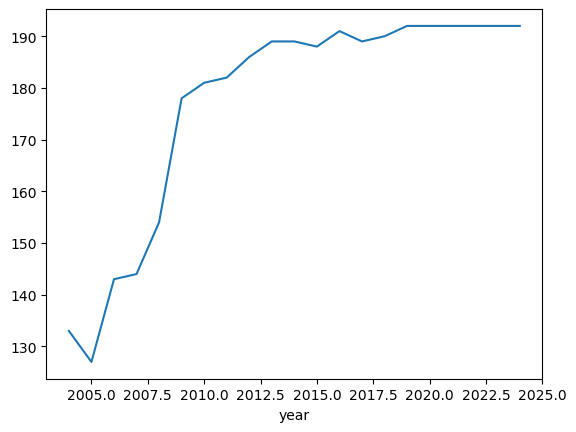

In [75]:
full_df.groupby('year').size().plot()

Plot turnover - does it look reasonable?

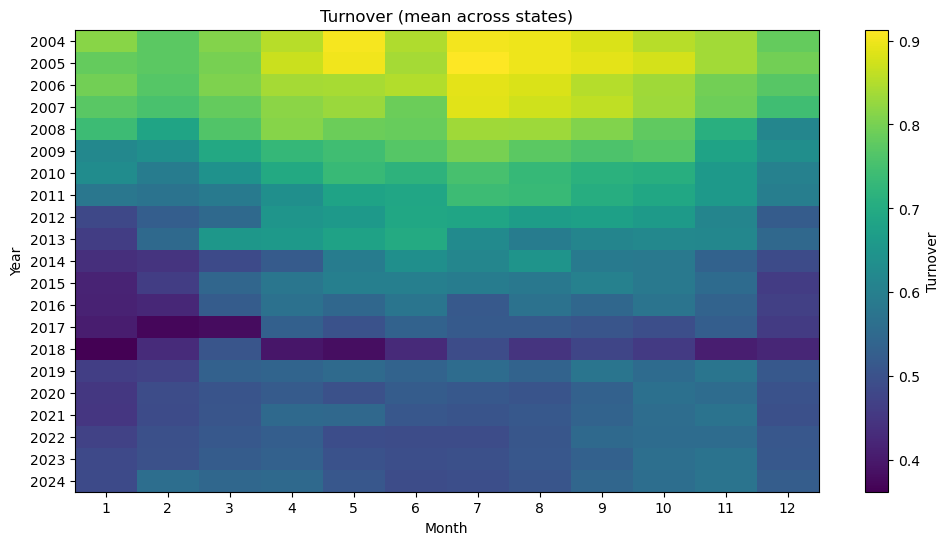

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = full_df.groupby(['year', 'month'])['turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Turnover (mean across states)")
plt.show()

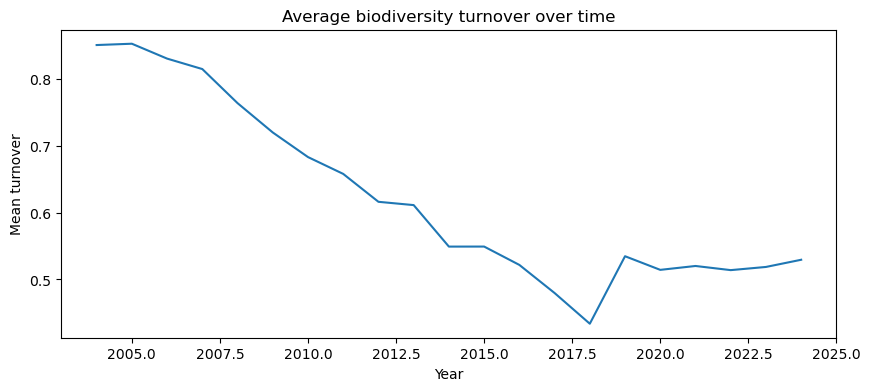

In [77]:
yearly = full_df.groupby('year')['turnover'].mean()

plt.figure(figsize=(10,4))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Mean turnover")
plt.title("Average biodiversity turnover over time")
plt.show()

Create binary 'biodiversity anomaly' outcome feature for classification model

1. compute baseline for state and month

In [117]:
# import pandas as pd
# full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

In [78]:
baseline = full_df.groupby(['state','month']).agg(
    mean_richness=('n_species','mean'),
    std_richness=('n_species','std')
).reset_index()

full_df = full_df.merge(baseline, on=['state','month'])

full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover,mean_richness,std_richness
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,2.333333,0.612179,0.833333,355.0,2.550228,93.0,0.196507,0.803493,231.428571,114.674135
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,2.000000,0.121404,1.333333,274.0,2.437751,108.0,0.217391,0.782609,276.900000,185.252005
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,0.000000,-0.483792,1.666667,815.0,2.911158,176.0,0.190533,0.809467,438.238095,290.009121
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,0.000000,-0.698102,1.666667,658.0,2.818226,197.0,0.128188,0.871812,743.523810,497.637581
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,0.000000,-0.067915,1.500000,914.0,2.960946,223.0,0.101671,0.898329,1135.380952,754.805039


2. Control for observation effort and year trend (with regression residuals)

In [119]:
# import statsmodels.api as sm

# X = sm.add_constant(full_df['log_n_obs']) # Creates dataframe of 1s (intercept) and log observations
# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [79]:
# # per-state trends

import statsmodels.api as sm

# Create design matrix
X = pd.get_dummies(full_df['state'], drop_first=True)

X['log_n_obs'] = full_df['log_n_obs']
# X['year'] = full_df['year']
full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
full_df['year_sq'] = full_df['year_centered'] ** 2
X['year_centered'] = full_df['year_centered']
X['year_sq'] = full_df['year_sq']

X = X.astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit model (richness)
model = sm.OLS(full_df['n_species'], X).fit()

full_df['expected_richness'] = model.predict(X)
full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

# Fit model (turnover)
model = sm.OLS(full_df['turnover'], X).fit()

full_df['expected_turnover'] = model.predict(X)
full_df['residual_turnover'] = full_df['turnover'] - full_df['expected_turnover']

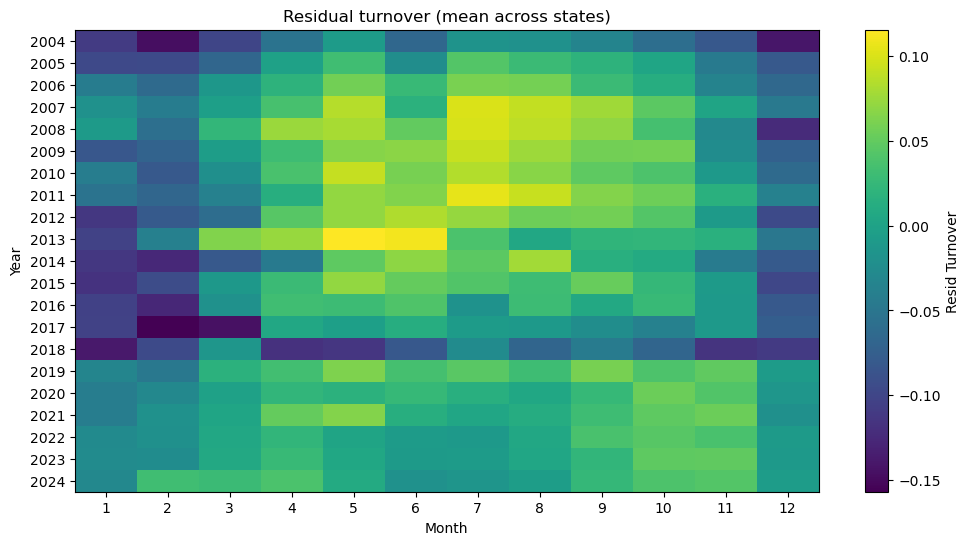

In [80]:
pivot = full_df.groupby(['year', 'month'])['residual_turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Resid Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Residual turnover (mean across states)")
plt.show()

In [122]:
# non-linear model

# import statsmodels.api as sm

# full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
# full_df['year_sq'] = full_df['year_centered'] ** 2

# X = full_df[['log_n_obs', 'year_centered', 'year_sq']]
# X = sm.add_constant(X)

# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [81]:
import numpy as np
full_df['sp_per_obs'] = np.log(full_df['n_species']) - np.log(full_df['n_obs'])

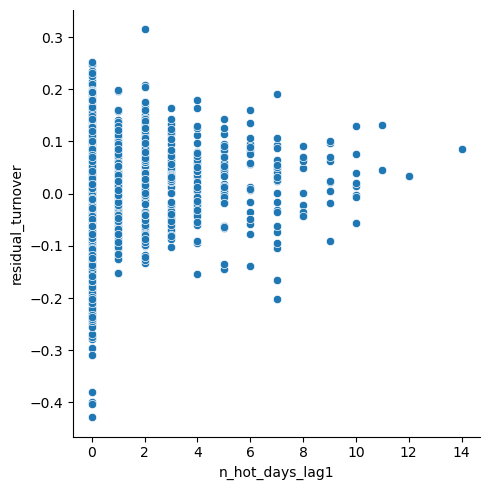

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_lag1',
            y='residual_turnover')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

3. Standardise residuals per state and month

In [83]:
full_df['residual_z'] = full_df.groupby(['state','month'])['residual'].transform(
    lambda x: (x - x.mean()) / x.std()
)

full_df['turnover_residual_z'] = full_df.groupby(['state','month'])['residual_turnover'].transform(
    lambda x: (x - x.mean()) / x.std()
)

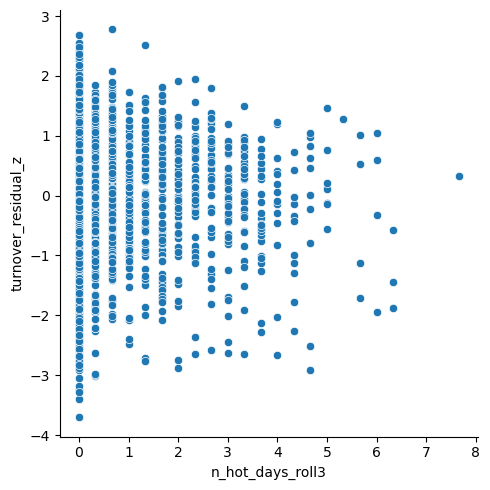

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_roll3',
            y='turnover_residual_z')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

4. Define binary anomaly  

interpretation:  
1 = biodiversity is unusually LOW for this state/month, given effort  
0 = normal or high biodiversity  

(or fine tune the threshold:  
-0.5 → more sensitive  
-1.0 → standard  
-1.5 → only extreme events
)

In [85]:
full_df['biodiversity_anomaly_standard'] = (full_df['residual_z'] < -1).astype(int)
full_df['biodiversity_anomaly_sensitive'] = (full_df['residual_z'] < -0.5).astype(int)
full_df['biodiversity_anomaly_conservative'] = (full_df['residual_z'] < -1.5).astype(int)

And for residual_turnover_z, higher values are 'bad':  

0 → expected turnover  
/>0 → higher-than-expected change  
< 0 → lower-than-expected change (more stable than expected)  

Use threshold based on quantiles in data - top 25% most extreme ecological change months

In [86]:
threshold = full_df['turnover_residual_z'].quantile(0.75)
full_df['high_turnover'] = (full_df['turnover_residual_z'] > threshold).astype(int)

In [87]:
full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,residual,expected_turnover,residual_turnover,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-148.774393,0.932992,-0.129499,-1.339518,1.121782,-2.363436,0,0,0,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-84.272976,0.937825,-0.155216,-0.930997,1.401059,-2.421703,0,0,0,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-224.619172,0.917485,-0.108017,-1.532704,0.196204,-2.192756,0,0,0,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-162.719972,0.921478,-0.049666,-1.206001,-0.703810,-1.170893,0,1,0,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-199.531103,0.915346,-0.017016,-1.410659,-0.798810,-0.294331,0,1,0,0


In [88]:
full_df.value_counts('biodiversity_anomaly_standard')

biodiversity_anomaly_standard
0    3151
1     565
Name: count, dtype: int64

In [89]:
full_df.value_counts('biodiversity_anomaly_sensitive')

biodiversity_anomaly_sensitive
0    2483
1    1233
Name: count, dtype: int64

In [91]:
full_df.value_counts('biodiversity_anomaly_conservative')

biodiversity_anomaly_conservative
0    3545
1     171
Name: count, dtype: int64

In [92]:
full_df.value_counts('high_turnover')

high_turnover
0    2787
1     929
Name: count, dtype: int64

plot biodiversity residuals over time

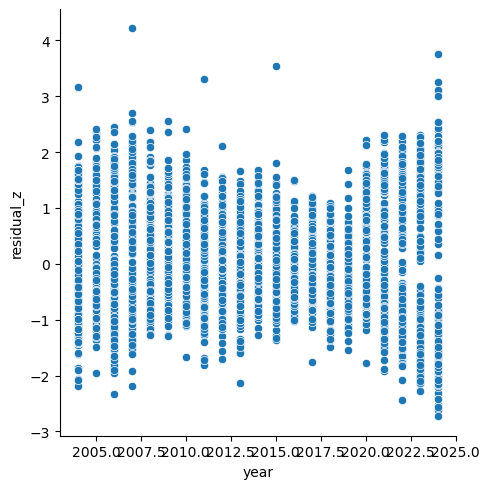

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='residual_z')
plt.show();

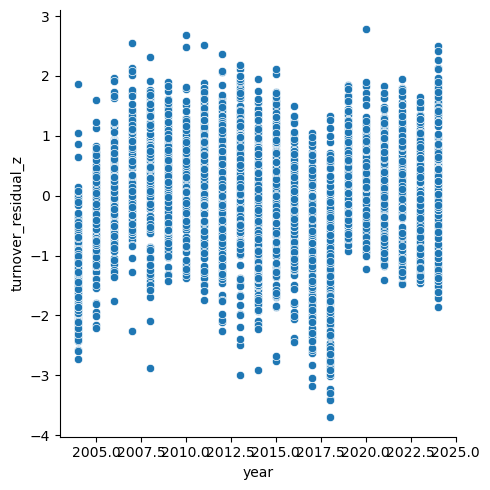

In [94]:
sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='turnover_residual_z')
plt.show();

Double check that lagged variable calculations worked correctly

In [95]:
full_df.loc[full_df['state'].isin(['Bayern', 'Berlin'])][['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']].groupby('state').head(3)

,state,monthyear,temp_anom_z,temp_anom_z_lag1
250,Bayern,1_2004,-0.484201,-0.255672
251,Bayern,2_2004,0.256806,-0.484201
252,Bayern,3_2004,-0.746567,0.256806
500,Berlin,1_2004,-0.731760,-0.016205
501,Berlin,2_2004,0.282089,-0.731760
502,Berlin,3_2004,0.109810,0.282089


Looks good - check if Jan lagged values are from December in previous year

In [96]:
(full_df.loc[(full_df['state'].isin(['Bayern', 'Berlin'])) 
            & (full_df['monthyear'].isin(['12_2004', '1_2005']))]
            [['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']]
            .groupby('state')
            .head(3))

,state,monthyear,temp_anom_z,temp_anom_z_lag1
261,Bayern,12_2004,-0.890507,-0.991200
262,Bayern,1_2005,0.008640,-0.890507
511,Berlin,12_2004,-0.136432,-0.731508
512,Berlin,1_2005,0.646846,-0.136432


Looks good!

Circular encoding of months  
(so that December (12) and January (1) are not interpreted as 11 months apart from each other)  

What This Achieves  
1. Cyclic continuity:  
- December → January is smooth, not “jumping” from 12 → 1  
2. Numeric representation:  
- Each month gets two numeric features  
- Model can now learn patterns like “winter months” or “summer months” continuously  
3. Avoids artificial ordering:  
- Tree-based models or linear models now handle seasonality correctly  

In [97]:
from numpy import pi, sin, cos

full_df['month_sin'] = sin(2*pi * full_df['month'] / 12)
full_df['month_cos'] = cos(2*pi * full_df['month'] / 12)

Now re-base the year to 0

In [98]:
full_df['year_offset'] = full_df['year'] - min(full_df['year'])

In [99]:
full_df

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-1.339518,1.121782,-2.363436,0,0,0,0,5.000000e-01,8.660254e-01,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.930997,1.401059,-2.421703,0,0,0,0,8.660254e-01,5.000000e-01,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-1.532704,0.196204,-2.192756,0,0,0,0,1.000000e+00,6.123234e-17,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-1.206001,-0.703810,-1.170893,0,1,0,0,8.660254e-01,-5.000000e-01,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-1.410659,-0.798810,-0.294331,0,1,0,0,5.000000e-01,-8.660254e-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3711,Thüringen,8_2024,2024,8,19.984138,30.950001,72.899994,2,2,18.361685,...,-2.386204,-1.488965,-0.965225,1,1,0,0,-8.660254e-01,-5.000000e-01,20
3712,Thüringen,9_2024,2024,9,15.468820,30.500000,88.400002,1,2,14.538055,...,-2.348772,-2.071312,0.034691,1,1,1,0,-1.000000e+00,-1.836970e-16,20
3713,Thüringen,10_2024,2024,10,11.061694,18.700001,62.299999,0,1,10.015421,...,-2.462351,-1.799099,-0.152637,1,1,1,0,-8.660254e-01,5.000000e-01,20
3714,Thüringen,11_2024,2024,11,4.483958,13.750000,53.499996,0,1,5.154050,...,-2.718522,-1.646196,1.406077,1,1,1,1,-5.000000e-01,8.660254e-01,20


Save full_df - ready for model pipeline

In [100]:
full_df.to_parquet('../Data/Processed/full_df.parquet')

In [101]:
full_df.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
3476,Schleswig-Holstein,12_2022,2022,12,1.936694,11.900000,100.199997,0,3,3.454947,...,-3.394206,-1.506149,0.741087,1,1,1,1,-2.449294e-16,1.000000e+00,18
1422,Hessen,6_2007,2007,6,17.333874,27.562000,135.399994,0,3,17.087580,...,-1.588832,-0.842571,0.306602,0,1,0,0,1.224647e-16,-1.000000e+00,3
2166,Nordrhein-Westfalen,10_2006,2006,10,13.021841,20.700001,68.800003,0,0,10.624839,...,-1.952497,-0.789724,0.260194,0,1,0,0,-8.660254e-01,5.000000e-01,2
1266,Hamburg,6_2015,2015,6,14.907361,26.502501,44.700001,0,1,16.713503,...,-1.384251,-0.284898,-0.849944,0,0,0,0,1.224647e-16,-1.000000e+00,11
2972,Sachsen,3_2019,2019,3,6.033737,17.750000,84.900002,0,3,4.149891,...,-2.252254,-0.477047,0.228755,0,0,0,0,1.000000e+00,6.123234e-17,15
2217,Nordrhein-Westfalen,1_2011,2011,1,1.490390,10.650001,86.300003,0,2,1.870454,...,-3.738490,0.261546,0.788163,0,0,0,1,5.000000e-01,8.660254e-01,7
2187,Nordrhein-Westfalen,7_2008,2008,7,17.072042,29.600000,150.899994,0,3,18.094753,...,-1.198596,-0.827619,1.539007,0,1,0,1,-5.000000e-01,-8.660254e-01,4
3448,Schleswig-Holstein,8_2020,2020,8,19.397243,30.400000,76.400002,2,2,17.372301,...,-2.468327,-0.058479,1.112570,0,0,0,1,-8.660254e-01,-5.000000e-01,16
2108,Niedersachsen,12_2022,2022,12,2.268280,15.150000,91.900002,0,3,3.666811,...,-3.618942,-1.037076,1.231630,1,1,0,1,-2.449294e-16,1.000000e+00,18
168,Baden-Württemberg,3_2018,2018,3,3.663643,14.650000,44.799999,0,1,4.780743,...,-3.267305,-0.861919,-0.400923,0,1,0,0,1.000000e+00,6.123234e-17,14
